In this problem, you will generate simulated data, and then perform
PCA and K-means clustering on the data.


(a) Generate a simulated data set with 20 observations in each of
three classes (i.e. 60 observations total), and 50 variables.
Hint: There are a number of functions in Python that you can
use to generate data. One example is the normal() method of
the random() function in numpy; the uniform() method is another
option. Be sure to add a mean shift to the observations in each
class so that there are three distinct classes.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

n_classes = 3
n_per_class = 20
p = 50
N = n_classes * n_per_class


offset = 3.5
centers = np.array([
    [ offset,  0.0,  0.0,  0.0,  0.0] + [0.0]*(p-5),
    [ 0.0,  offset, 0.0,  0.0,  0.0] + [0.0]*(p-5),
    [-offset, 0.0,  0.0,  0.0,  0.0] + [0.0]*(p-5),
])

X_list, y_list = [], []
for k in range(n_classes):
    Xk = rng.normal(loc=0.0, scale=1.0, size=(n_per_class, p)) + centers[k]
    X_list.append(Xk)
    y_list.append(np.full(n_per_class, k))

X = np.vstack(X_list)
y_true = np.concatenate(y_list)

print(f"X shape: {X.shape}, y shape: {y_true.shape}")
print("Number of samples in each group：", pd.Series(y_true).value_counts().sort_index().to_dict())


X shape: (60, 50), y shape: (60,)
Number of samples in each group： {0: 20, 1: 20, 2: 20}


(b) Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate
the observations in each of the three classes. If the three classes
appear separated in this plot, then continue on to part (c). If
not, then return to part (a) and modify the simulation so that
there is greater separation between the three classes. Do not
continue to part (c) until the three classes show at least some
separation in the first two principal component score vectors.





 (b) PCA variation explained proportion
PC1    0.173390
PC2    0.080922
dtype: float64


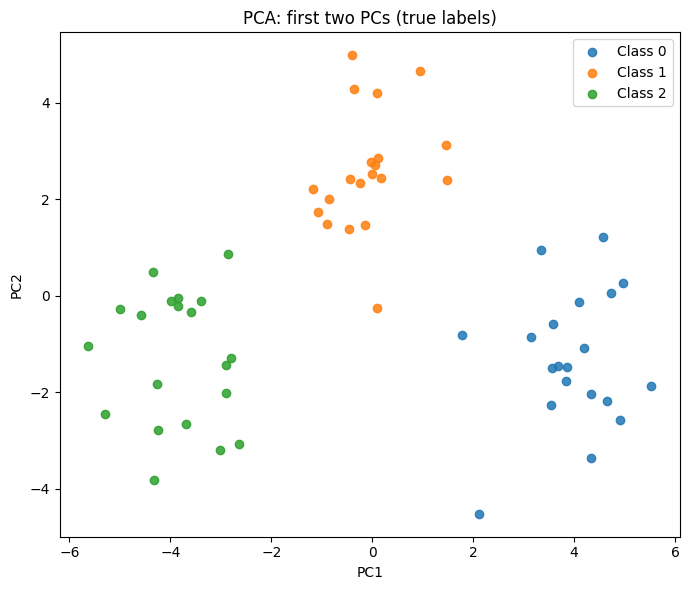

In [25]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

print("\n (b) PCA variation explained proportion")
print(pd.Series(pca.explained_variance_ratio_, index=["PC1","PC2"]))

plt.figure(figsize=(7,6))
for k in range(n_classes):
    mask = (y_true == k)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Class {k}", alpha=0.85)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: first two PCs (true labels)")
plt.legend()
plt.tight_layout()
# plt.savefig("b_pca_true_labels.png", dpi=150)
plt.show()

The PCA scatter plot should show a clear separation of the three clusters on the (PC1, PC2) plane.

(c) Perform K-means clustering of the observations with K = 3.
How well do the clusters that you obtained in K-means clustering compare to the true class labels?
Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering
will arbitrarily number the clusters, so you cannot simply check
whether the true class labels and clustering labels are the same.


In [26]:
def clustering_report(y_true, y_pred, title=""):
    ct = pd.crosstab(pd.Series(y_true, name="True"),
                     pd.Series(y_pred, name="Cluster"))
    print(f"\n{title}")
    print(ct)
    return ct

def purity_like_score(table: pd.DataFrame) -> float:
    return np.sum(table.max(axis=0)) / table.values.sum()

kmeans3 = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
y_k3 = kmeans3.fit_predict(X)
ct3 = clustering_report(y_true, y_k3, title="=== (c) KMeans on raw data, K=3 ===")



=== (c) KMeans on raw data, K=3 ===
Cluster   0   1   2
True               
0         0  20   0
1        20   0   0
2         0   0  20


(d) Perform K-means clustering with K = 2. Describe your results.

In [27]:

kmeans2 = KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE)
y_k2 = kmeans2.fit_predict(X)
ct2 = clustering_report(y_true, y_k2, title="=== (d) KMeans on raw data, K=2 ===")



=== (d) KMeans on raw data, K=2 ===
Cluster   0   1
True           
0         0  20
1        20   0
2        20   0



(e) Now perform K-means clustering with K = 4, and describe your
results.

In [28]:

kmeans4 = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)
y_k4 = kmeans4.fit_predict(X)
ct4 = clustering_report(y_true, y_k4, title="=== (e) KMeans on raw data, K=4 ===")




=== (e) KMeans on raw data, K=4 ===
Cluster   0   1   2  3
True                  
0        20   0   0  0
1         1   0  19  0
2         0  12   0  8


Using K=4 may split a cluster into two smaller clusters, also decreasing purity.

(f) Now perform K-means clustering with K = 3 on the first two
principal component score vectors, rather than on the raw data.
That is, perform K-means clustering on the 60 × 2 matrix of
which the first column is the first principal component score
vector, and the second column is the second principal component
score vector. Comment on the results.


=== (f) KMeans on (PC1, PC2), K=3 ===
Cluster   0   1   2
True               
0         0   0  20
1        20   0   0
2         0  20   0


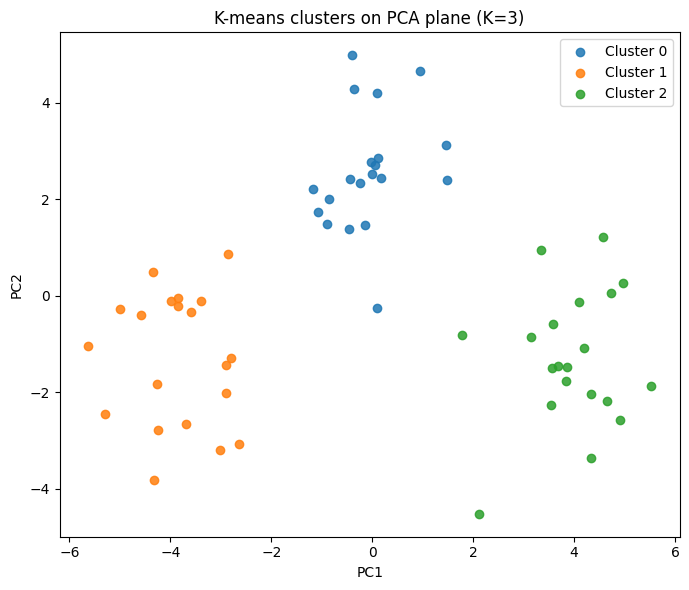

In [29]:

kmeans3_pca = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
y_k3_pca = kmeans3_pca.fit_predict(X_pca)
ct3_pca = clustering_report(y_true, y_k3_pca, title="=== (f) KMeans on (PC1, PC2), K=3 ===")

plt.figure(figsize=(7,6))
for c in np.unique(y_k3_pca):
    mask = (y_k3_pca == c)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {int(c)}", alpha=0.85)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-means clusters on PCA plane (K=3)")
plt.legend()
plt.tight_layout()
# plt.savefig("f_kmeans_on_pca.png", dpi=150)
plt.show()


Using only (PC1, PC2) for clustering, if the information is concentrated in the first two principal components, the results are often similar to (c) and more visually clear.

(g) Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have
standard deviation one. How do these results compare to those
obtained in (b)? Explain.

In [30]:

scaler = StandardScaler(with_mean=True, with_std=True)
X_std = scaler.fit_transform(X)

kmeans3_std = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
y_k3_std = kmeans3_std.fit_predict(X_std)
ct3_std = clustering_report(y_true, y_k3_std, title="(g) KMeans on standardized data, K=3")


summary_df = pd.DataFrame({
    "Setting": ["Raw, K=3", "Raw, K=2", "Raw, K=4", "PC(2D), K=3", "Standardized, K=3"],
    "Purity~": [
        purity_like_score(ct3),
        purity_like_score(ct2),
        purity_like_score(ct4),
        purity_like_score(ct3_pca),
        purity_like_score(ct3_std),
    ]
})
print("\n Brief comparison (Purity-like, higher is better)")
print(summary_df.to_string(index=False))


(g) KMeans on standardized data, K=3
Cluster  0  1   2
True             
0        2  7  11
1        8  5   7
2        5  9   6

 Brief comparison (Purity-like, higher is better)
          Setting  Purity~
         Raw, K=3 1.000000
         Raw, K=2 0.666667
         Raw, K=4 0.983333
      PC(2D), K=3 1.000000
Standardized, K=3 0.466667


Using K=3 after normalizing the variables can prevent a single high-variance variable from dominating the distances, generally resulting in more stable clustering.